# 🔍 Credit Scoring — Notebook 04: SHAP Explainability
**Author:** Abu Jafar Sisty  
**Conference:** COMPAS 2026 — IEEE, University of Dhaka  
**Dataset:** Give Me Some Credit — 150,000 records

---
**Objective:** Explain best model (XGBoost) predictions using SHAP

## 1️⃣ Install & Import Libraries

In [1]:
# !pip install shap

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import pickle
import json
import warnings
import os
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

SEED = 42
np.random.seed(SEED)

os.makedirs('../figures', exist_ok=True)
os.makedirs('../outputs', exist_ok=True)

print('✅ Libraries loaded!')
print(f'   SHAP version: {shap.__version__}')

✅ Libraries loaded!
   SHAP version: 0.51.0


## 2️⃣ Load Data & Best Model

In [2]:
# Load dataset
df = pd.read_csv('../data/raw/cs-training.csv', index_col=0)

# --- Same Cleaning as Notebook 03 ---
df = df[(df['age'] >= 18) & (df['age'] <= 100)]
df['MonthlyIncome'].fillna(df['MonthlyIncome'].median(), inplace=True)
df['NumberOfDependents'].fillna(0, inplace=True)
df['RevolvingUtilizationOfUnsecuredLines'] = df['RevolvingUtilizationOfUnsecuredLines'].clip(0, 1)
for col in ['DebtRatio', 'MonthlyIncome']:
    df[col] = df[col].clip(0, df[col].quantile(0.99))
for col in ['NumberOfTime30-59DaysPastDueNotWorse',
            'NumberOfTime60-89DaysPastDueNotWorse',
            'NumberOfTimes90DaysLate']:
    df[col] = df[col].clip(0, 10)

# --- Same Feature Engineering ---
df['TotalTimesPastDue'] = (
    df['NumberOfTime30-59DaysPastDueNotWorse'] +
    df['NumberOfTime60-89DaysPastDueNotWorse'] +
    df['NumberOfTimes90DaysLate']
)
df['WeightedLatePay'] = (
    df['NumberOfTime30-59DaysPastDueNotWorse'] * 1 +
    df['NumberOfTime60-89DaysPastDueNotWorse'] * 2 +
    df['NumberOfTimes90DaysLate'] * 3
)
df['MonthlyDebt']        = df['DebtRatio'] * df['MonthlyIncome']
df['NetMonthlyIncome']   = df['MonthlyIncome'] - df['MonthlyDebt']
df['IncomePerDependent'] = df['MonthlyIncome'] / (df['NumberOfDependents'] + 1)
df['DebtPerDependent']   = df['MonthlyDebt']   / (df['NumberOfDependents'] + 1)
df['HighUtilization']    = (df['RevolvingUtilizationOfUnsecuredLines'] > 0.7).astype(int)
df['MaxedOut']           = (df['RevolvingUtilizationOfUnsecuredLines'] > 0.95).astype(int)
df['IsYoung']            = (df['age'] < 30).astype(int)
df['IsSenior']           = (df['age'] > 60).astype(int)
df['AgeBucket']          = pd.cut(df['age'], bins=[0,25,35,45,55,65,100], labels=[0,1,2,3,4,5]).astype(int)
df['HasLatePay']         = (df['TotalTimesPastDue'] > 0).astype(int)
df['HasSeriousLatePay']  = (df['NumberOfTimes90DaysLate'] > 0).astype(int)
df['HasOpenLoans']       = (df['NumberOfOpenCreditLinesAndLoans'] > 0).astype(int)
df['HasRealEstate']      = (df['NumberRealEstateLoansOrLines'] > 0).astype(int)
df['IsNegativeCash']     = (df['NetMonthlyIncome'] < 0).astype(int)
df['UtilizationXLatePay'] = df['RevolvingUtilizationOfUnsecuredLines'] * df['TotalTimesPastDue']
df['DebtRatioXAge']      = df['DebtRatio'] * df['age']

# Fix NaN
df = df.replace([np.inf, -np.inf], np.nan)
df = df.fillna(df.median(numeric_only=True))

# Split
target_col = 'SeriousDlqin2yrs'
X = df.drop(columns=[target_col])
y = df[target_col]
feature_names = list(X.columns)

X_train, X_test, y_train, y_test = train_test_split(
    X.values, y.values, test_size=0.2, random_state=SEED, stratify=y.values
)

# Convert to DataFrame for SHAP
X_test_df  = pd.DataFrame(X_test,  columns=feature_names)
X_train_df = pd.DataFrame(X_train, columns=feature_names)

# Load best model
with open('../models/best_credit_model.pkl', 'rb') as f:
    best_model = pickle.load(f)

print(f'✅ Best model loaded: {type(best_model).__name__}')
print(f'✅ Features: {len(feature_names)}')
print(f'✅ Test samples: {X_test_df.shape[0]:,}')

✅ Best model loaded: XGBClassifier
✅ Features: 28
✅ Test samples: 29,998


## 3️⃣ Compute SHAP Values

In [3]:
print('🔄 Computing SHAP values...')

# TreeExplainer for XGBoost
explainer = shap.TreeExplainer(best_model)

# Use 1000 samples for speed
X_sample = X_test_df.sample(n=min(1000, len(X_test_df)), random_state=SEED)
shap_values = explainer.shap_values(X_sample)

# Handle binary classification
if isinstance(shap_values, list):
    shap_vals = shap_values[1]
else:
    shap_vals = shap_values

print(f'✅ SHAP values computed!')
print(f'   Shape: {shap_vals.shape}')

🔄 Computing SHAP values...
✅ SHAP values computed!
   Shape: (1000, 28)


## 4️⃣ SHAP Summary Bar Plot (Global Feature Importance)

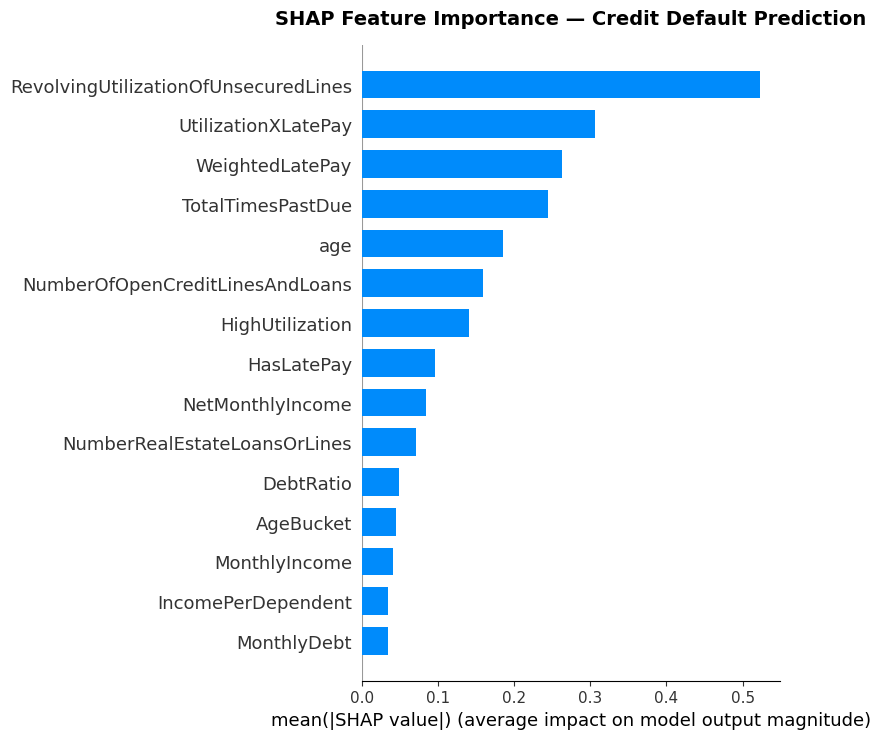

✅ Saved: figures/shap_bar.png


In [4]:
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_vals, X_sample,
    feature_names=feature_names,
    plot_type='bar',
    show=False,
    max_display=15
)
plt.title('SHAP Feature Importance — Credit Default Prediction',
          fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../figures/shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: figures/shap_bar.png')

## 5️⃣ SHAP Beeswarm Summary Plot

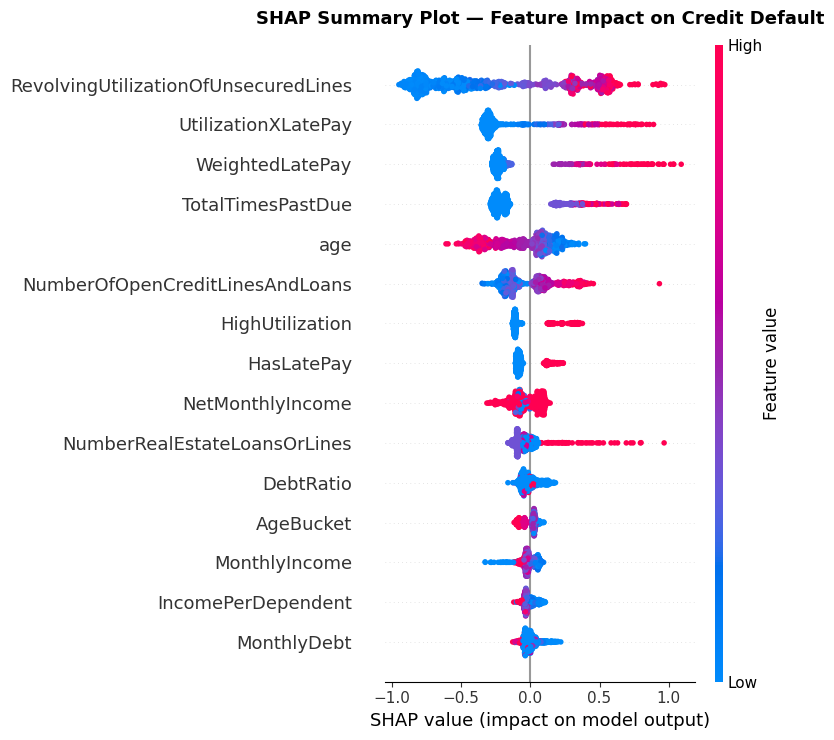

✅ Saved: figures/shap_summary.png


In [5]:
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_vals, X_sample,
    feature_names=feature_names,
    show=False,
    max_display=15
)
plt.title('SHAP Summary Plot — Feature Impact on Credit Default',
          fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../figures/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: figures/shap_summary.png')

## 6️⃣ SHAP Waterfall Plot (Single Prediction Explanation)

Sample prediction: No Default (probability: 0.3616)


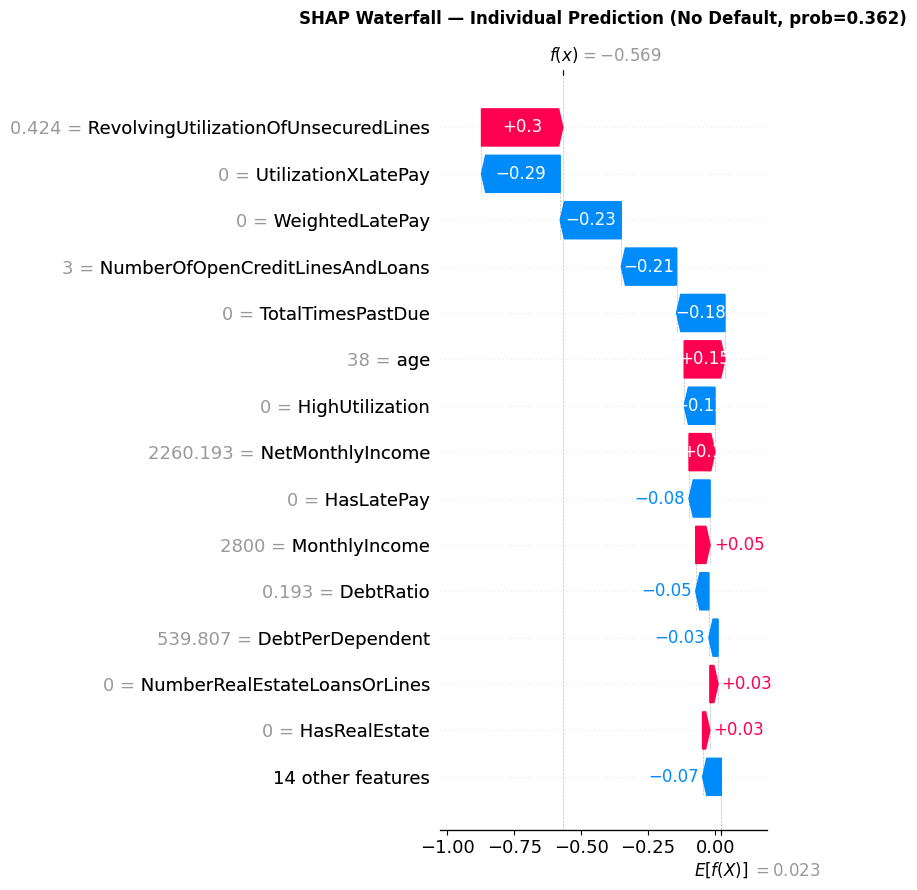

✅ Saved: figures/shap_waterfall.png


In [6]:
# Find a default case (y=1) for explanation
y_test_sample = y_test[:len(X_sample)]
default_indices = np.where(y_test_sample == 1)[0]
idx = default_indices[0] if len(default_indices) > 0 else 0

# Predict
sample = X_sample.iloc[[idx]]
pred   = best_model.predict(sample)[0]
prob   = best_model.predict_proba(sample)[0][1]
label  = 'Default' if pred == 1 else 'No Default'
print(f'Sample prediction: {label} (probability: {prob:.4f})')

# Waterfall
expected_val = explainer.expected_value
if isinstance(expected_val, list):
    expected_val = expected_val[1]

explanation = shap.Explanation(
    values=shap_vals[idx],
    base_values=expected_val,
    data=X_sample.iloc[idx].values,
    feature_names=feature_names
)

plt.figure(figsize=(10, 6))
shap.waterfall_plot(explanation, show=False, max_display=15)
plt.title(f'SHAP Waterfall — Individual Prediction ({label}, prob={prob:.3f})',
          fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../figures/shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: figures/shap_waterfall.png')

## 7️⃣ Top Feature Importance Table

In [7]:
mean_shap = np.abs(shap_vals).mean(axis=0)
feature_imp = pd.DataFrame({
    'Feature':    feature_names,
    'Mean |SHAP|': mean_shap
}).sort_values('Mean |SHAP|', ascending=False)

print('===== TOP 15 FEATURES BY SHAP =====')
print(feature_imp.head(15).to_string(index=False))

feature_imp.to_csv('../outputs/shap_feature_importance.csv', index=False)
print('\n✅ Saved: outputs/shap_feature_importance.csv')

===== TOP 15 FEATURES BY SHAP =====
                             Feature  Mean |SHAP|
RevolvingUtilizationOfUnsecuredLines     0.522953
                 UtilizationXLatePay     0.306590
                     WeightedLatePay     0.262862
                   TotalTimesPastDue     0.244436
                                 age     0.184799
     NumberOfOpenCreditLinesAndLoans     0.159202
                     HighUtilization     0.140329
                          HasLatePay     0.096559
                    NetMonthlyIncome     0.084092
        NumberRealEstateLoansOrLines     0.071364
                           DebtRatio     0.048189
                           AgeBucket     0.044766
                       MonthlyIncome     0.040261
                  IncomePerDependent     0.034964
                         MonthlyDebt     0.034680

✅ Saved: outputs/shap_feature_importance.csv


## 8️⃣ SHAP Feature Importance Chart (Paper Figure)

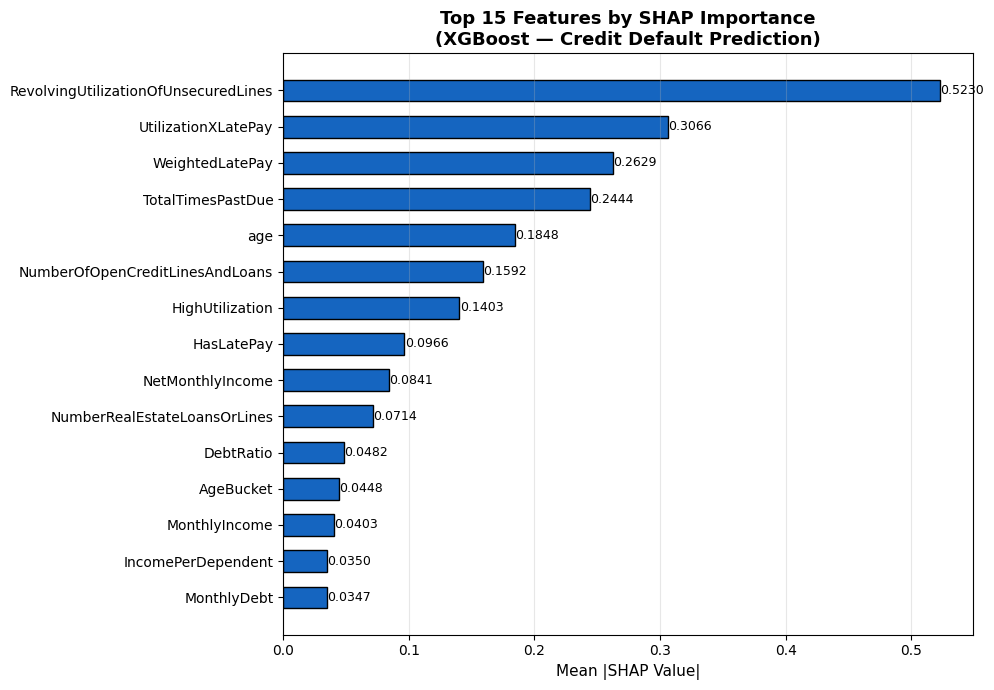

✅ Saved: figures/shap_importance_chart.png


In [8]:
top15 = feature_imp.head(15).sort_values('Mean |SHAP|')

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(top15['Feature'], top15['Mean |SHAP|'],
               color='#1565C0', edgecolor='black', height=0.6)
for bar in bars:
    ax.text(bar.get_width() + 0.0002,
            bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.4f}',
            va='center', fontsize=9)
ax.set_title('Top 15 Features by SHAP Importance\n(XGBoost — Credit Default Prediction)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Mean |SHAP Value|', fontsize=11)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/shap_importance_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: figures/shap_importance_chart.png')

## 9️⃣ Save Predictions

In [9]:
y_pred_all = best_model.predict(X_test_df)
y_prob_all = best_model.predict_proba(X_test_df)[:, 1]

predictions_df = X_test_df.copy()
predictions_df['Actual']      = y_test
predictions_df['Predicted']   = y_pred_all
predictions_df['Probability'] = y_prob_all.round(4)
predictions_df['Risk_Label']  = predictions_df['Predicted'].map(
    {1: 'Default', 0: 'No Default'}
)

predictions_df.to_csv('../outputs/predictions.csv', index=False)

# Sample input for API testing
import json
sample_input = X_test_df.iloc[0].to_dict()
with open('../outputs/sample_input.json', 'w') as f:
    json.dump(sample_input, f, indent=2)

print(f'✅ Predictions saved: {len(predictions_df):,} rows')
print('✅ Sample input saved: outputs/sample_input.json')

✅ Predictions saved: 29,998 rows
✅ Sample input saved: outputs/sample_input.json


## 🔟 Final Summary

In [10]:
print('='*60)
print('   NOTEBOOK 04 COMPLETE — SHAP ANALYSIS')
print('='*60)
print('\n📊 Figures generated:')
print('   figures/shap_bar.png            ← Global importance bar')
print('   figures/shap_summary.png        ← Beeswarm summary')
print('   figures/shap_waterfall.png      ← Single prediction')
print('   figures/shap_importance_chart.png ← Top 15 features')
print('\n📁 Outputs saved:')
print('   outputs/shap_feature_importance.csv')
print('   outputs/predictions.csv')
print('   outputs/sample_input.json')
print('\n===== TOP 10 IMPORTANT FEATURES =====')
print(feature_imp.head(10)[['Feature','Mean |SHAP|']].to_string(index=False))
print('\n➡️  Next: Run Streamlit app!')

   NOTEBOOK 04 COMPLETE — SHAP ANALYSIS

📊 Figures generated:
   figures/shap_bar.png            ← Global importance bar
   figures/shap_summary.png        ← Beeswarm summary
   figures/shap_waterfall.png      ← Single prediction
   figures/shap_importance_chart.png ← Top 15 features

📁 Outputs saved:
   outputs/shap_feature_importance.csv
   outputs/predictions.csv
   outputs/sample_input.json

===== TOP 10 IMPORTANT FEATURES =====
                             Feature  Mean |SHAP|
RevolvingUtilizationOfUnsecuredLines     0.522953
                 UtilizationXLatePay     0.306590
                     WeightedLatePay     0.262862
                   TotalTimesPastDue     0.244436
                                 age     0.184799
     NumberOfOpenCreditLinesAndLoans     0.159202
                     HighUtilization     0.140329
                          HasLatePay     0.096559
                    NetMonthlyIncome     0.084092
        NumberRealEstateLoansOrLines     0.071364

➡️  Next: Ru

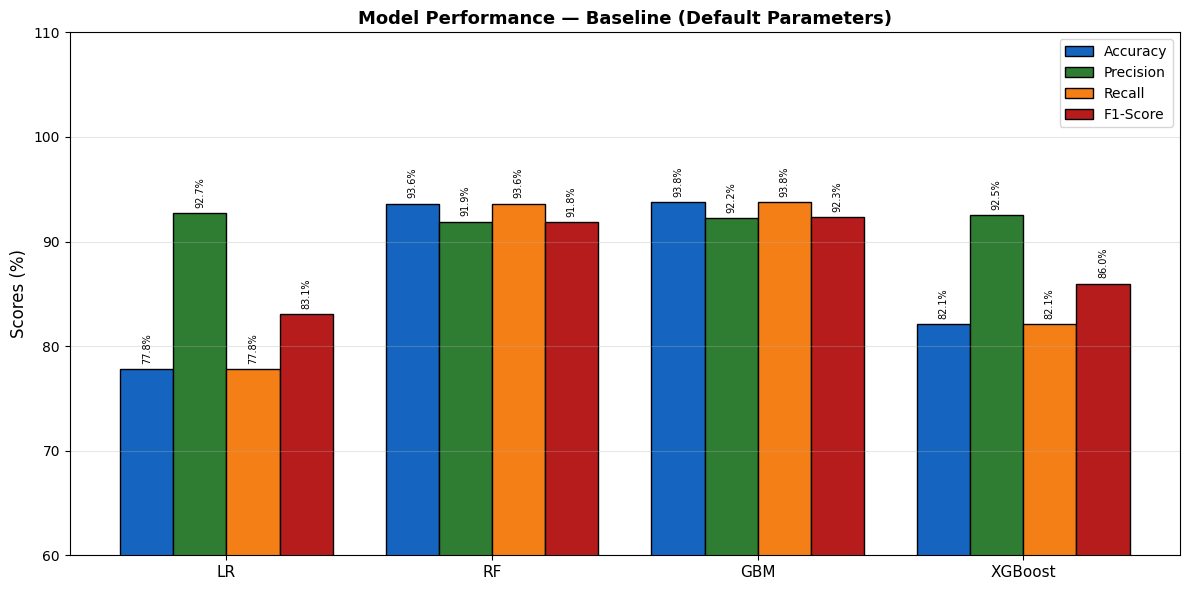

✅ Saved: figures/performance_baseline.png


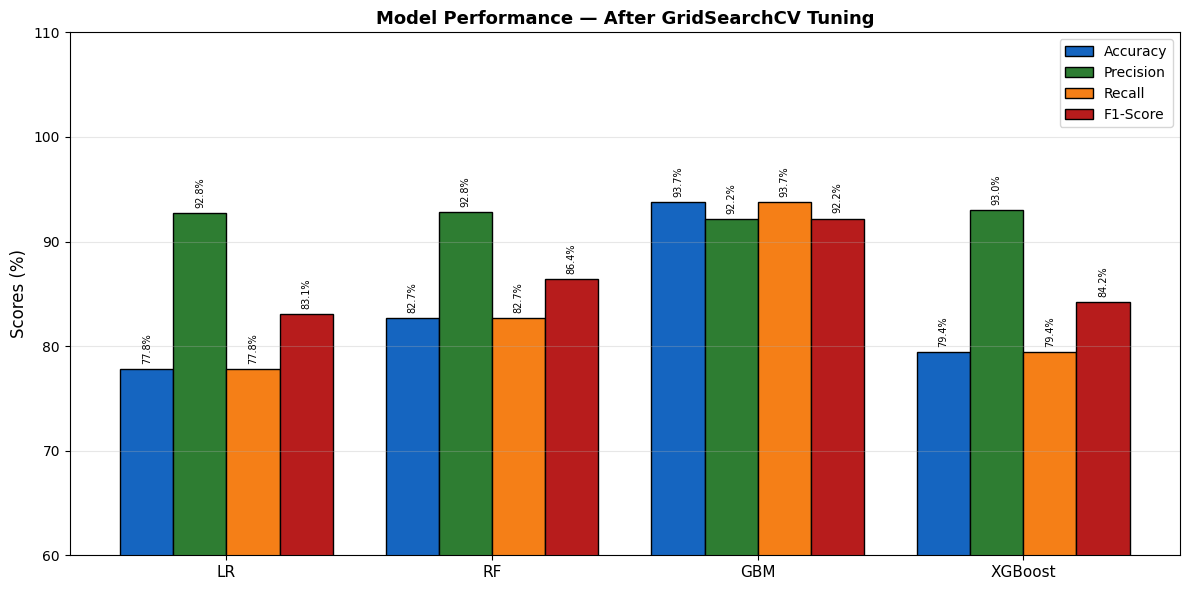

✅ Saved: figures/performance_gridsearch.png


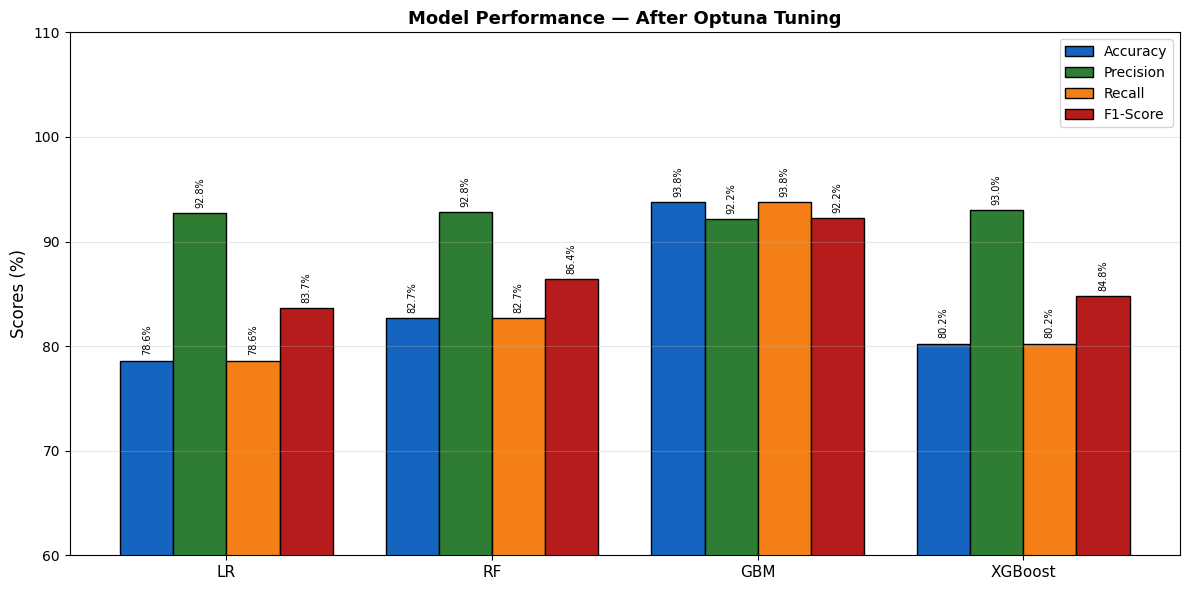

✅ Saved: figures/performance_optuna.png


In [11]:
import matplotlib.pyplot as plt
import numpy as np

models = ['LR', 'RF', 'GBM', 'XGBoost']

baseline = {
    'Accuracy':  [0.7782, 0.9363, 0.9377, 0.8213],
    'Precision': [0.9274, 0.9190, 0.9224, 0.9252],
    'Recall':    [0.7782, 0.9363, 0.9377, 0.8213],
    'F1-Score':  [0.8308, 0.9183, 0.9230, 0.8597]
}

gridsearch = {
    'Accuracy':  [0.7782, 0.8269, 0.9373, 0.7939],
    'Precision': [0.9275, 0.9283, 0.9215, 0.9300],
    'Recall':    [0.7782, 0.8269, 0.9373, 0.7939],
    'F1-Score':  [0.8308, 0.8641, 0.9219, 0.8419]
}

optuna_results = {
    'Accuracy':  [0.7861, 0.8269, 0.9377, 0.8023],
    'Precision': [0.9275, 0.9283, 0.9215, 0.9300],
    'Recall':    [0.7861, 0.8269, 0.9377, 0.8023],
    'F1-Score':  [0.8365, 0.8641, 0.9225, 0.8477]
}

def plot_grouped_bar(data, title, filename):
    metrics = list(data.keys())
    x = np.arange(len(models))
    width = 0.2
    colors = ['#1565C0', '#2E7D32', '#F57F17', '#B71C1C']

    fig, ax = plt.subplots(figsize=(12, 6))
    for i, metric in enumerate(metrics):
        bars = ax.bar(x + i*width,
                     [v*100 for v in data[metric]],
                     width, label=metric,
                     color=colors[i], edgecolor='black')
        for bar in bars:
            ax.text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 0.5,
                   f'{bar.get_height():.1f}%',
                   ha='center', va='bottom', fontsize=7, rotation=90)

    ax.set_xticks(x + width*1.5)
    ax.set_xticklabels(models, fontsize=11)
    ax.set_ylim(60, 110)
    ax.set_ylabel('Scores (%)', fontsize=12)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'../figures/{filename}', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'✅ Saved: figures/{filename}')

plot_grouped_bar(baseline,
    'Model Performance — Baseline (Default Parameters)',
    'performance_baseline.png')

plot_grouped_bar(gridsearch,
    'Model Performance — After GridSearchCV Tuning',
    'performance_gridsearch.png')

plot_grouped_bar(optuna_results,
    'Model Performance — After Optuna Tuning',
    'performance_optuna.png')

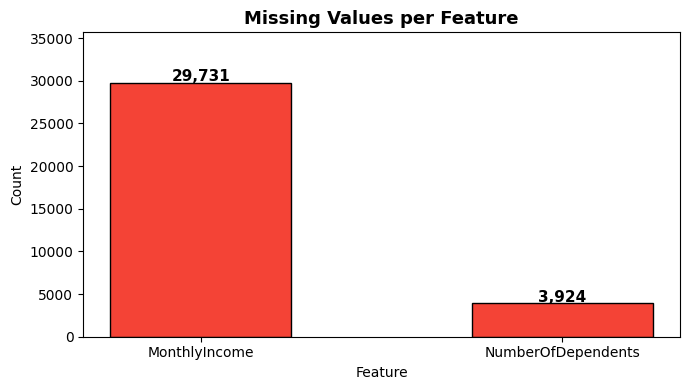

✅ Saved: figures/missing_values.png


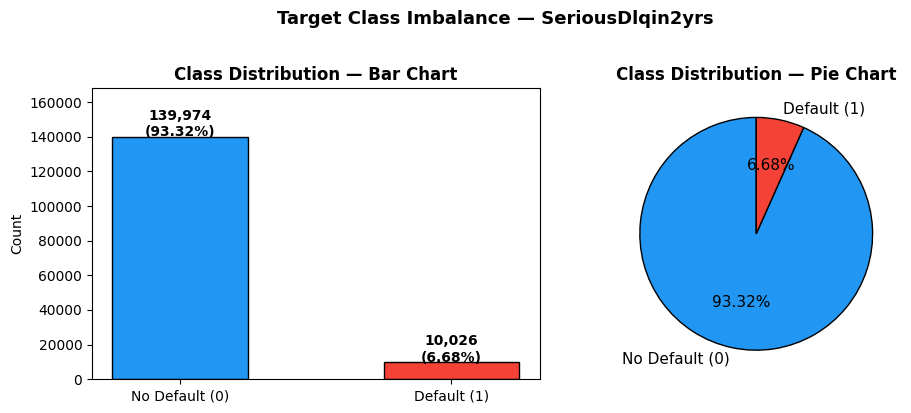

✅ Saved: figures/class_imbalance.png


In [12]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

df_orig = pd.read_csv('../data/raw/cs-training.csv', index_col=0)

# ── Fig 1: Missing Values ──────────────────────────────────
missing = df_orig.isnull().sum()
missing = missing[missing > 0]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(missing.index, missing.values, 
              color='#F44336', edgecolor='black', width=0.5)
for bar, val in zip(bars, missing.values):
    ax.text(bar.get_x() + bar.get_width()/2, 
            bar.get_height() + 200,
            f'{val:,}', ha='center', fontsize=11, fontweight='bold')
ax.set_title('Missing Values per Feature', fontsize=13, fontweight='bold')
ax.set_ylabel('Count')
ax.set_xlabel('Feature')
ax.set_ylim(0, max(missing.values) * 1.2)
plt.tight_layout()
plt.savefig('../figures/missing_values.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: figures/missing_values.png')

# ── Fig 2: Class Imbalance ────────────────────────────────
counts = df_orig['SeriousDlqin2yrs'].value_counts()
labels = ['No Default (0)', 'Default (1)']
values = [counts[0], counts[1]]
colors = ['#2196F3', '#F44336']

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Bar chart
bars = axes[0].bar(labels, values, color=colors, edgecolor='black', width=0.5)
for bar, val in zip(bars, values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 200,
                f'{val:,}\n({val/sum(values)*100:.2f}%)',
                ha='center', fontweight='bold', fontsize=10)
axes[0].set_title('Class Distribution — Bar Chart', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_ylim(0, max(values) * 1.2)

# Pie chart
axes[1].pie(values, labels=labels, colors=colors,
            autopct='%1.2f%%', startangle=90,
            textprops={'fontsize': 11},
            wedgeprops={'edgecolor': 'black'})
axes[1].set_title('Class Distribution — Pie Chart', fontsize=12, fontweight='bold')

plt.suptitle('Target Class Imbalance — SeriousDlqin2yrs', 
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../figures/class_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: figures/class_imbalance.png')